# Saliency Plots

In [2]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
os.chdir("../")
sys.path.append("utils")
from saliency_utils import *
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st

from sklearn.linear_model import LinearRegression
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
regression_who_results = pd.read_csv("/home/sak0914/who-analysis/results/Regression_Final_June2024_Tier1.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["Lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
coll_2014['position'] = coll_2014['position'].astype(str)
del coll_2014["#lineage"]

freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
df_isolates = pd.read_csv("data_processing/samples_pass_geno_QC.csv")

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)

# Ethionamide

4 loci!
Plotting significant saliency scores for fabG1-inhA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethR using 10 max scores and 10 min scores
Plotting significant saliency scores for mshA using 10 max scores and 10 min scores


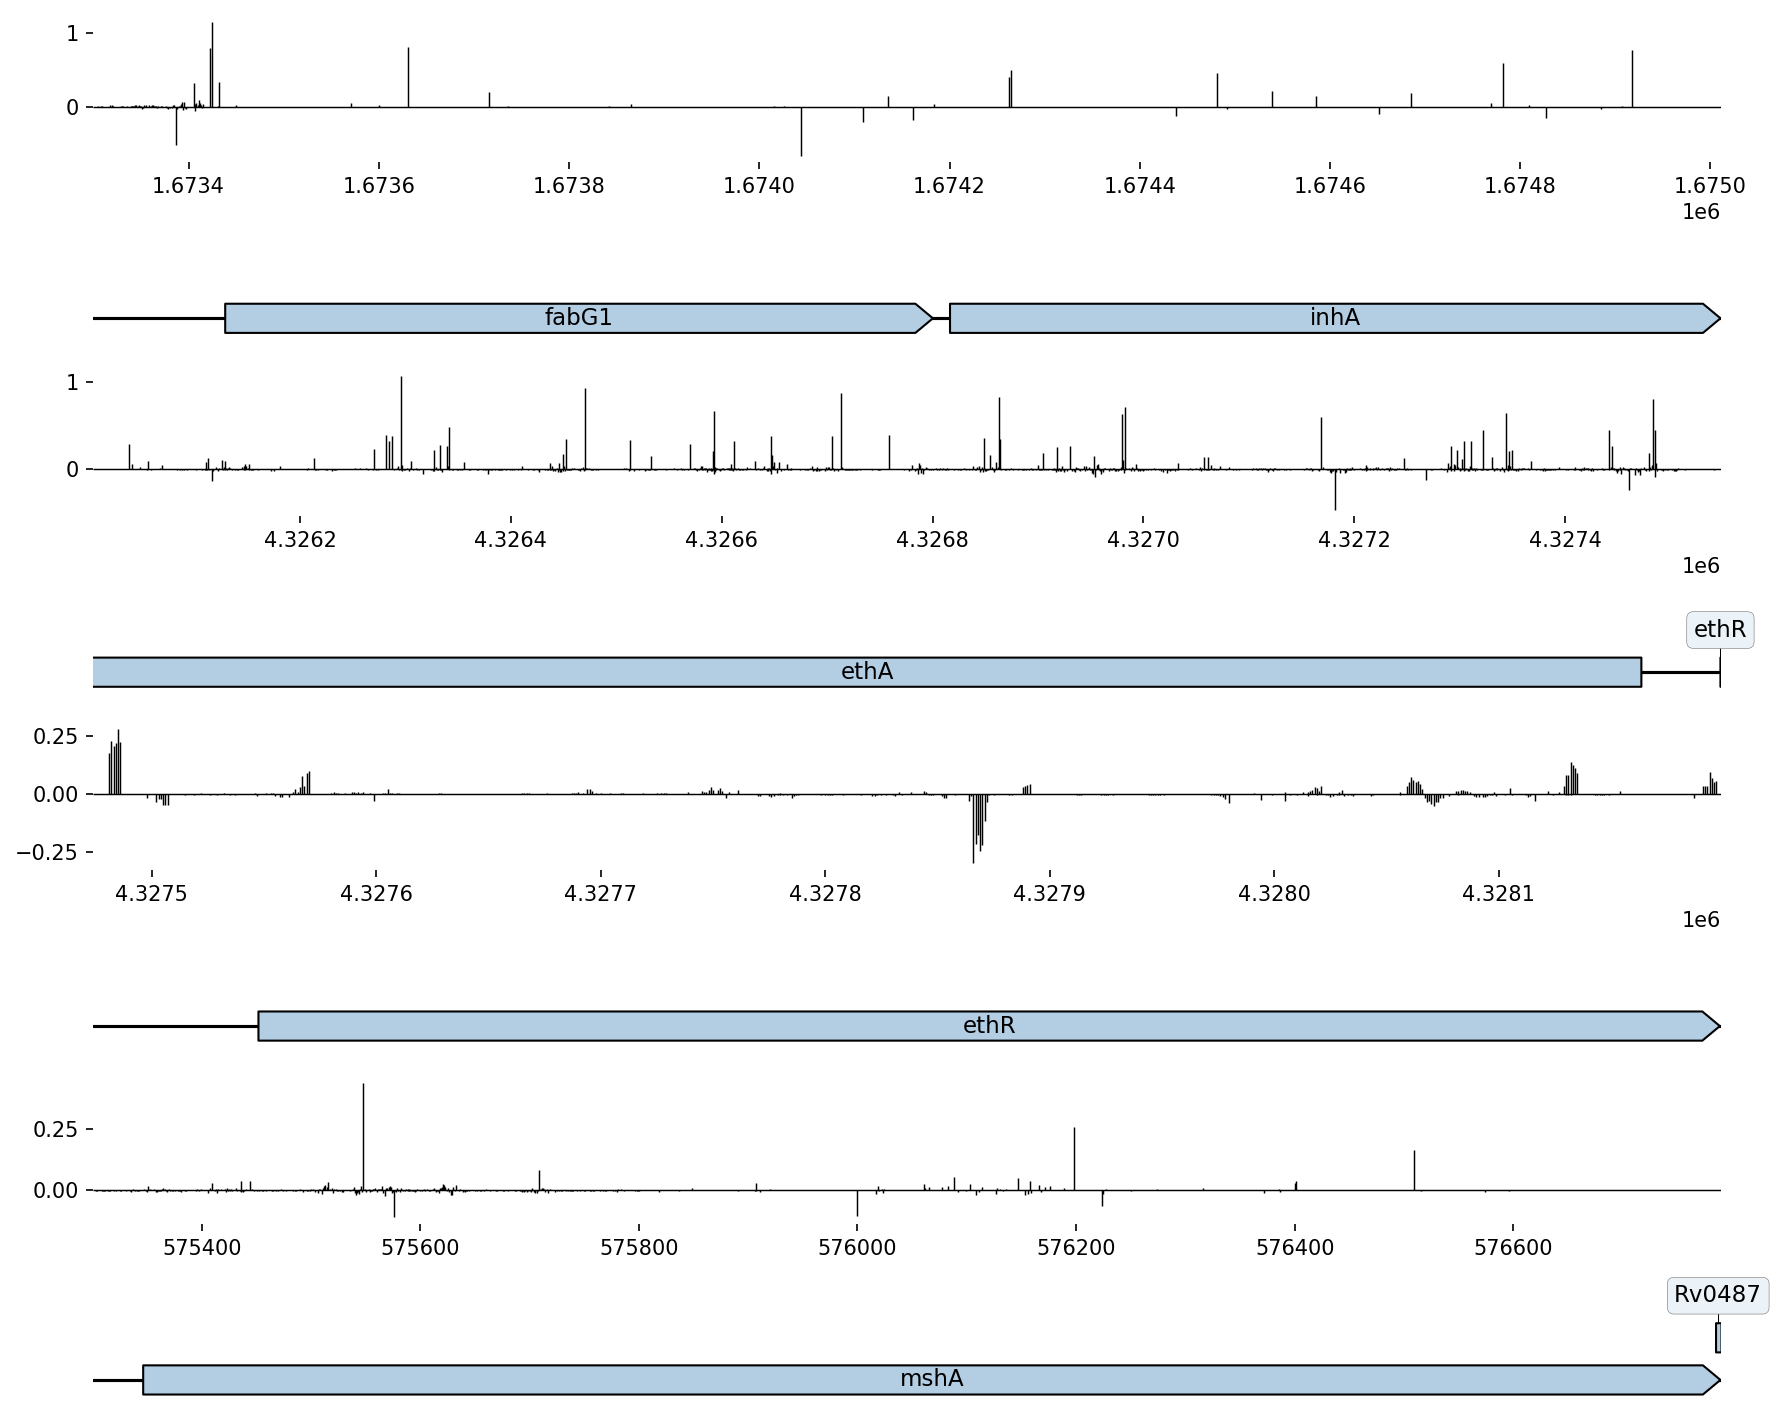

In [2]:
drug = 'ETH'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_amino_acid")

ETH_df, _ = generate_saliency_plots(drug,
                                      model_path,
                                      kwargs['tier1_loci'],
                                      fasta_dir=kwargs['genotype_input_directory'],
                                      cat_to_check=["1"],
                                      save=True,
                                      significance=True,
                                      sig_thresh=0.05,
                                     )

ETH_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [4]:
ETH_df.query("Gene=='mshA' & Max_Sig==1").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
249,mshA,575548.0,0.437149,0.0,1.0,0.0
1511,mshA,mshA_29,0.346031,0.0,1.0,0.0
916,mshA,576198.0,0.259195,0.0,1.0,0.0
1510,mshA,mshA_28,0.226015,0.0,1.0,0.0
1228,mshA,576509.0,0.164155,0.0,1.0,0.0
...,...,...,...,...,...,...
160,mshA,575460.0,0.000287,0.0,1.0,0.0
6,mshA,575307.0,0.000255,0.0,1.0,0.0
5,mshA,575306.0,0.000253,0.0,1.0,0.0
253,mshA,575552.0,0.000130,0.0,1.0,0.0


In [25]:
ETH_df.query("Gene=='mshA' & Pos==576198")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
916,mshA,576198.0,0.259195,0.0,1.0,0.0


In [ ]:
mshA_c.575548C>T

In [27]:
isolate_variants.query("POS==576198 & drug=='Ethionamide'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
445924,576198,T,C,PASS,7825.0,False,1.0,225.0,35.0,60.0,0.0,0.0,missense_variant,mshA,c.851T>C,p.Leu284Pro,mshA_p.Leu284Pro,Ethionamide,3) Uncertain significance,SAMEA7555751


In [26]:
pos = 576198
locus = 'mshA'

locus_idx = kwargs['tier1_loci'].index(locus)
ref = ETH_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETH_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETH_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETH_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: T


({'A': 0.0, 'C': 0.25919506, 'T': 0.0, 'G': 0.0, '-': 0.0},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0})

In [21]:
ETH_seqDict[locus].loc[ETH_seqDict[locus][pos]=='T']

,575301.0,575302.0,575303.0,575304.0,575305.0,575306.0,575307.0,575308.0,575309.0,575310.0,...,mshA_28,mshA_29,576783.0,576784.0,576785.0,576786.0,576787.0,576788.0,576789.0,576790.0
Isolate,,,,,,,,,,,,,,,,,,,,,
SAMEA7542054,T,C,G,G,C,T,G,A,C,G,...,-,-,G,C,G,C,G,T,G,A


In [7]:
model_path
ETH_tier2_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

7 loci!
Plotting significant saliency scores for fabG1-inhA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethA using 10 max scores and 10 min scores
Plotting significant saliency scores for ethR using 10 max scores and 10 min scores
Plotting significant saliency scores for mshA using 10 max scores and 10 min scores
Plotting significant saliency scores for Rv0565c using 10 max scores and 10 min scores
Plotting significant saliency scores for ndh using 10 max scores and 10 min scores
Plotting significant saliency scores for Rv3083 using 10 max scores and 10 min scores


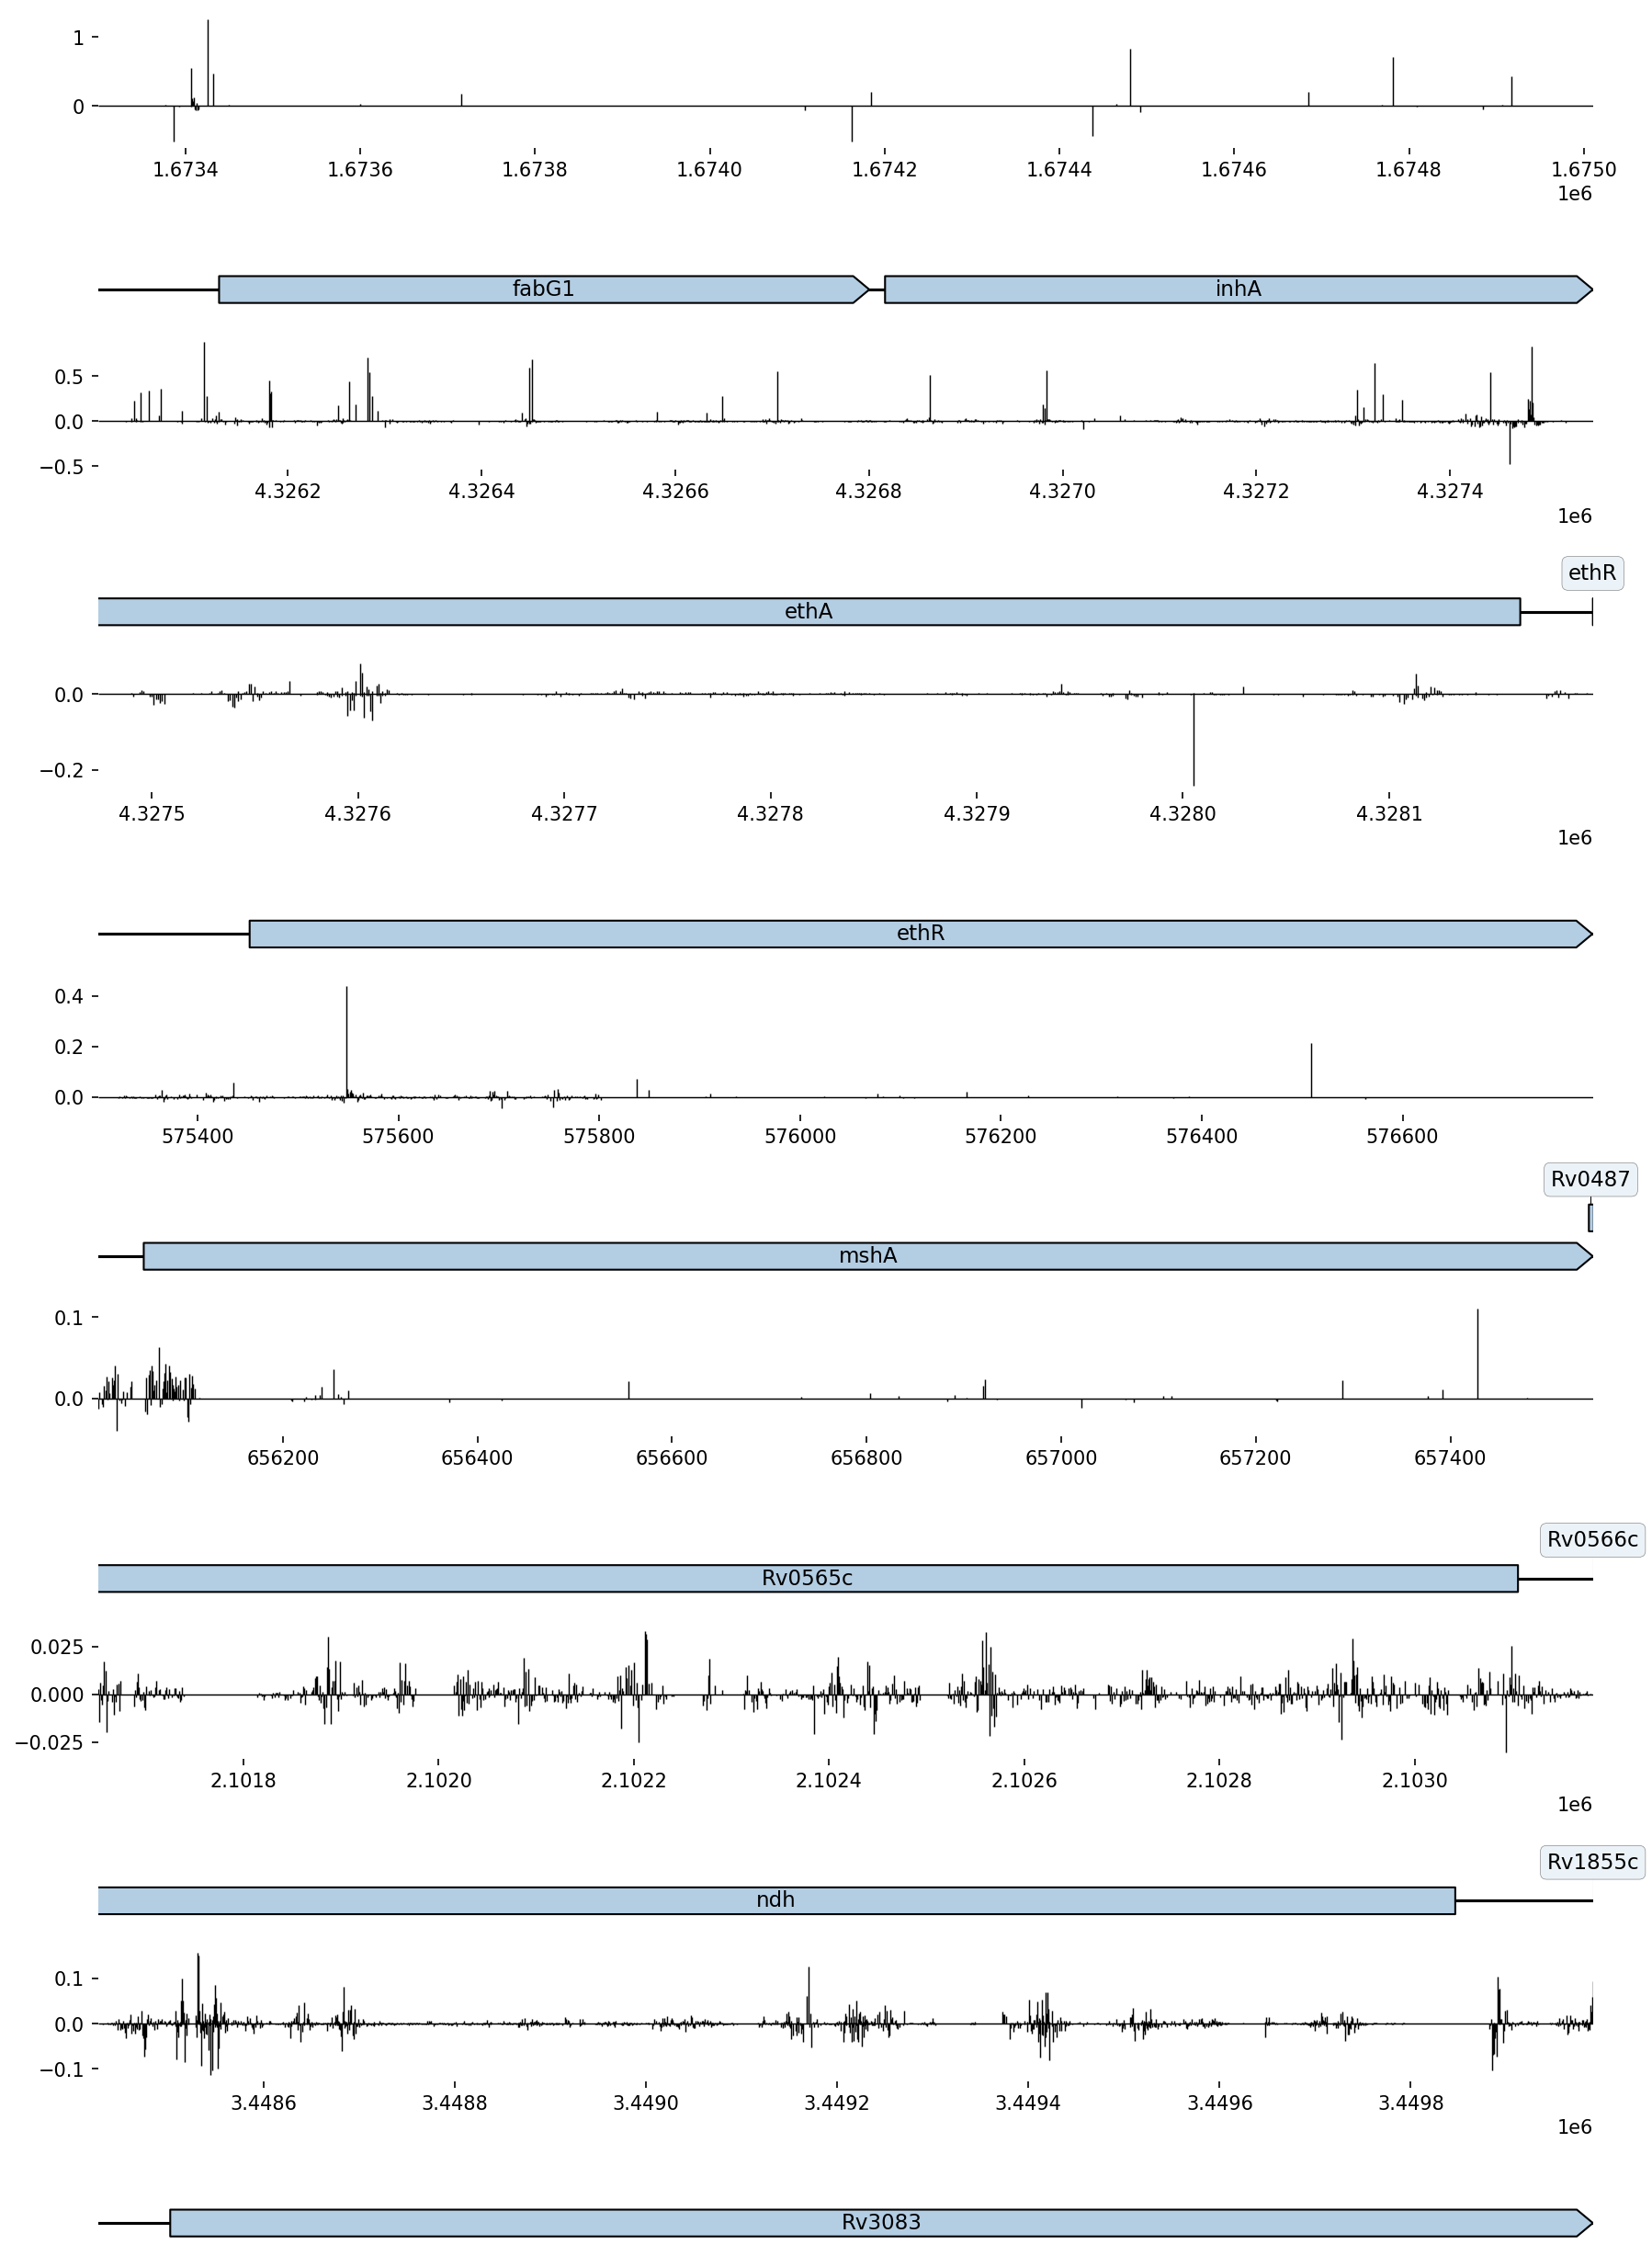

In [3]:
drug = 'ETH'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_tier2_amino_acid")

ETH_tier2_df, ETH_seqDict = generate_saliency_plots(drug,
                                              model_path,
                                              kwargs['tier1_loci'] + kwargs['tier2_loci'],
                                              fasta_dir=kwargs['genotype_input_directory'],
                                              cat_to_check=["1"],
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

ETH_tier2_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [38]:
ETH_tier2_df.query("Gene=='Rv3083' & Max_Sig==1").sort_values("Max", ascending=False).head()

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
1115,Rv3083,3449528.0,0.388848,-0.003245,1.0,1.0
124,Rv3083,3448547.0,0.198360,0.000000,1.0,0.0
798,Rv3083,3449212.0,0.107808,0.000000,1.0,0.0
98,Rv3083,3448521.0,0.107067,-0.001416,1.0,1.0
1582,Rv3083,3449990.0,0.086205,0.000000,1.0,0.0


In [39]:
pos = 3449528
locus = 'Rv3083'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETH_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETH_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: T


({'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.3888483, '-': 0.0027349405},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': -0.0032452545})

In [40]:
isolate_variants.query("POS==@pos")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
667881,3449528,T,G,PASS,2838.0,False,0.99,76.0,39.0,60.0,0.0,0.0,missense_variant,Rv3083,c.1025T>G,p.Ile342Ser,Rv3083_p.Ile342Ser,Ethionamide,3) Uncertain significance,SAMEA8741480


In [48]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA8741480' & drug=='Ethionamide'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
667847,575907,C,T,PASS,1923.0,False,1.00,50.0,38.0,60.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,SAMEA8741480
667852,657081,C,T,PASS,3562.0,False,1.00,93.0,39.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,SAMEA8741480
667853,657142,C,T,PASS,3513.0,False,1.00,91.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,SAMEA8741480
667881,3449528,T,G,PASS,2838.0,False,0.99,76.0,39.0,60.0,0.0,0.0,missense_variant,Rv3083,c.1025T>G,p.Ile342Ser,Rv3083_p.Ile342Ser,Ethionamide,3) Uncertain significance,SAMEA8741480
667892,4326463,GA,G,PASS,0.0,False,1.00,69.0,0.0,60.0,0.0,69.0,frameshift_variant,ethA,c.1010delT,p.Ile337fs,ethA_p.Ile337fs,Ethionamide,2) Assoc w R - Interim,SAMEA8741480


In [41]:
ETH_tier2_df.query("Gene=='Rv0565c' & Max_Sig==1").sort_values("Max", ascending=False).head()

,Gene,Pos,Max,Min,Max_Sig,Min_Sig
119,Rv0565c,657428.0,0.221384,0.0,1.0,0.0
1006,Rv0565c,656555.0,0.108258,0.0,1.0,0.0
1556,Rv0565c,656026.0,0.087116,0.0,1.0,0.0
1546,Rv0565c,656036.0,0.080465,0.0,1.0,0.0
1561,Rv0565c,656021.0,0.068325,0.0,1.0,0.0


In [42]:
pos = 657428
locus = 'Rv0565c'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETH_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETH_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

Reference: G


({'A': 0.0, 'C': 0.0, 'T': 0.22138439, 'G': 0.0, '-': 0.0},
 {'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0})

In [43]:
isolate_variants.query("POS==@pos")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
675590,657428,C,A,PASS,4967.0,False,0.83,387.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.43G>T,p.Val15Phe,Rv0565c_p.Val15Phe,Ethionamide,3) Uncertain significance,SAMEA8741644


In [47]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA8741644' & drug=='Ethionamide'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
675583,575907,C,T,PASS,7923.0,False,1.00,207.0,38.0,60.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,SAMEA8741644
675588,657081,C,T,PASS,12109.0,False,1.00,318.0,38.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,SAMEA8741644
675589,657142,C,T,PASS,15783.0,False,1.00,408.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,SAMEA8741644
675590,657428,C,A,PASS,4967.0,False,0.83,387.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.43G>T,p.Val15Phe,Rv0565c_p.Val15Phe,Ethionamide,3) Uncertain significance,SAMEA8741644
675610,1673432,T,C,PASS,12892.0,False,1.00,334.0,39.0,60.0,0.0,0.0,intergenic_region,Rv1482c-fabG1,n.1673432T>C,NaN,inhA_c.-770T>C,Ethionamide,2) Assoc w R - Interim,SAMEA8741644
675635,4326087,GT,G,PASS,0.0,False,1.00,273.0,40.0,60.0,0.0,272.0,frameshift_variant,ethA,c.1386delA,p.Arg463fs,ethA_p.Arg463fs,Ethionamide,2) Assoc w R - Interim,SAMEA8741644


In [44]:
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

In [46]:
df_ETO_phenos.query("ROLLINGDB_ID=='SAMEA8741644'")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
8266,SAMEA8741644,7H10,5.0,7.5,10.0,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.00694,2.2.1,2.2.1.1.1,"beijing,canetti,mungi","europe/russia_B0/W148_outbreak,lin2.2.1",NaN,2,0,1.0,2-1,train_set


# Moxifloxacin

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores


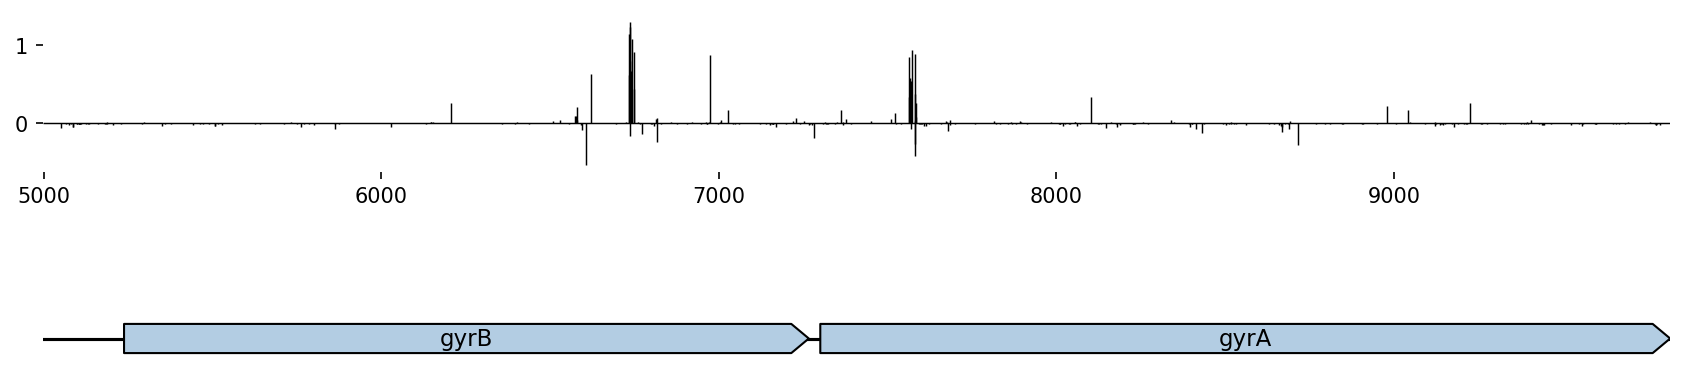

In [8]:
drug = 'MXF'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_amino_acid")

MXF_df, MXF_seqDict = generate_saliency_plots(drug,
                                              model_path,
                                              kwargs['tier1_loci'],
                                              fasta_dir=kwargs['genotype_input_directory'],
                                              cat_to_check=["1"],
                                              save=False,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

#BDQ_scores = sparse.load_npz(os.path.join(results_dir, model_path, "saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

# Pyrazinamide

4 loci!
Plotting significant saliency scores for pncA using 10 max scores and 10 min scores
Plotting significant saliency scores for panD using 10 max scores and 10 min scores
Plotting significant saliency scores for rpsA using 10 max scores and 10 min scores
Plotting significant saliency scores for clpC1 using 10 max scores and 10 min scores


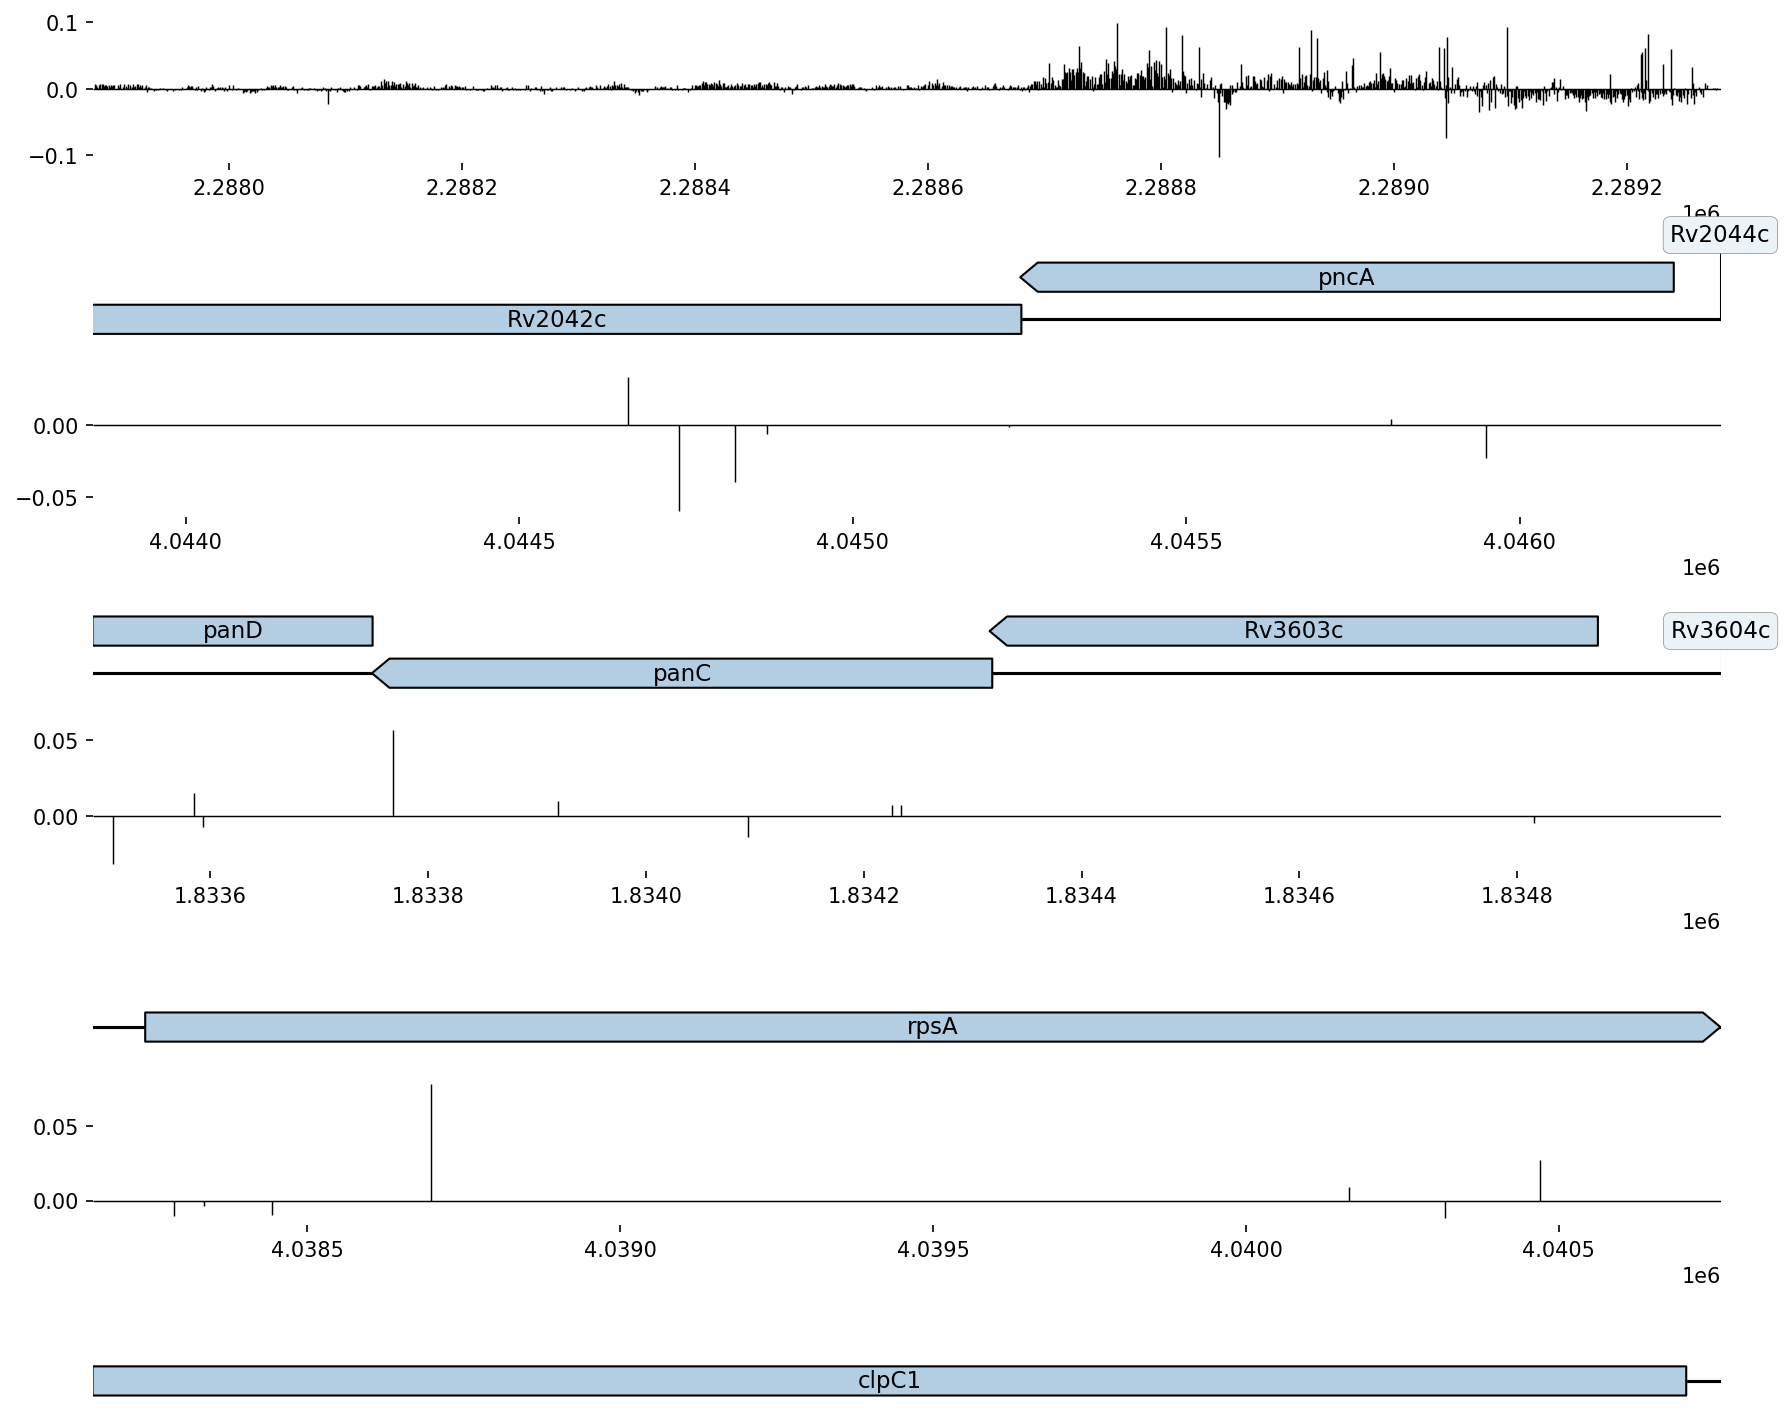

In [3]:
drug = 'PZA'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_amino_acid")

PZA_df, PZA_seqDict = generate_saliency_plots(drug,
                                              model_path,
                                              kwargs['tier1_loci'],
                                              fasta_dir=kwargs['genotype_input_directory'],
                                              cat_to_check=["1"],
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

PZA_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [4]:
model_loci.query("Locus=='clpC1'")

,Locus,Start,End,Sense
24,clpC1,4038157,4040759,-


# Lineage Saliency Plots

In [3]:
def generate_lineage_saliency_plot(drug, model_path, lineage_mat=lineages_matrix, annot_thresh=0.25, significance=True, savefName=None):
    
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv")).query("category=='train_set'")
    df_phenos["log2_MIC"] = np.log2(df_phenos[f"{drug}_midpoint"])
    mean_log_mic = np.mean(df_phenos["log2_MIC"])
    
    
    ################################### STEP 1: MAKE A DATAFRAME OF THE LINEAGE SNPS (AND PEPTIDE LENGTHS, IF SO) WITH SCORES ###################################


    if "_peptide" in model_path:
        genes_lst = pd.read_csv(os.path.join(results_dir, drug, "gene_peptide_lengths.csv"), index_col=[0]).columns
        genes_lst = [gene.replace("_length", "") for gene in genes_lst]
    else:
        genes_lst = []
        
    # get only the training or testing set and subset the lineage matrix too
    lineage_mat = lineage_mat.loc[df_phenos["ROLLINGDB_ID"]]
    
    saliency_dir = os.path.join(results_dir, model_path, "saliency")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "mlp_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": list(genes_lst) + list(lineage_mat.columns), 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0),
                                      # 'Mean': lineage_scores.mean(axis=0), # take the average activation of each lineage SNP across the training isolates
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["Lineage", "position"]], on="position")
    

    ################################### STEP 2: COMPUTE AVERAGE MIC OF EACH LINEAGE DIVIDED BY AVERAGE OF THE WHOLE DATASET ###################################


    lineage_scores_df['Mean_log2_MIC'] = mean_log_mic
    
    # add log2-MIC to get averaged per lineage later
    lineage_mat = lineage_mat.merge(df_phenos[["ROLLINGDB_ID", "log2_MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    # get the prediction for H37Rv from the in silico analysis directory
    df_insilico = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis", "lineage_SNP_predictions.csv"))
    H37Rv_pred = df_insilico.query("Lineage=='MT_H37Rv'")['log2_pred_MIC'].values[0]
    
    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineage_mat.loc[lineage_mat[row["position"]]==1]["log2_MIC"].mean()
        lineage_scores_df.loc[i, ["log2_MIC", "MIC"]] = [log2_MIC, np.exp2(log2_MIC)]
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = row["position"], row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        # keep track of the number of training isolates of each lineae
        lineage_scores_df.loc[i, 'Num_Isolates'] = len(isolates_in_lineage)

        # hypothesis test to compare mean of isolates in a particular lineage to the entire dataset
        if len(isolates_in_lineage) > 0:

            if log2_MIC > mean_log_mic:
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug}_midpoint"].values, 
                                               df_phenos[f"{drug}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_pval"] = np.nan

        
    ################################### STEP 3: GET P-VALUES FOR USING PERMUTATION MODEL SCORES ###################################

    
    # get permutation score results
    if significance:

        lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/mlp_scores*.npy"))
        assert len(lineage_scores_paths) == 10

        lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

        lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values

        # get p-values from the permutation test
        for i, row in lineage_scores_df.iterrows():

            # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
            if row["Max"] > 0:
                lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > row["Max"])
            else:
                lineage_scores_df.loc[i, "Max_pval"] = np.nan

            if row["Min"] < 0:
                lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < row["Min"])
            else:
                lineage_scores_df.loc[i, "Min_pval"] = np.nan

        lineage_scores_df["Bonferroni_MIC_pval"] = lineage_scores_df["MIC_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_pval"])])
        
        # assert len(lineage_scores_df.query("MIC_pval > BH_MIC_pval")) == 0
        assert len(lineage_scores_df.query("MIC_pval > Bonferroni_MIC_pval")) == 0

        # smallest possible non-zero p-value is 0.1, so get p-values smaller than that
        significant_lineages = lineage_scores_df.query("(Max_pval < 0.1 & Max > 0) | (Min_pval < 0.1 & Min < 0)").reset_index(drop=True)
        
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have significant saliency scores")

    else:
        significant_lineages = lineage_scores_df.query("Max > 0 | Min < 0")

        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have non-zero saliency scores")
    
    freq_thresh = 2
    significant_lineages = significant_lineages.query("Num_Isolates >= @freq_thresh")
    print(f"{len(significant_lineages)} lineages have at least {freq_thresh} isolates")
    
        
    ################################### STEP 4: CREATE AN AGGREGATE SALIENCY SCORE FOR EACH LINEAGE ###################################
    

    # the threshold for significance is 0.1 because the only possible p-values are 0, 0.1, 0.2, 0.3....1 because there were 10 permuted models
    pval_thresh = 0.1
    
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():
        
        if significance:

            
            if row["Max_pval"] < pval_thresh:

                # if Max is significant, but not Min
                if pd.isnull(row["Min_pval"]) or row["Min_pval"] >= pval_thresh:
                    significant_lineages.loc[i, "plot_score"] = row["Max"]

                else:
                    # take the one with the absolute value if both are significant because it's likely that the one with the larger absolute magnitude 
                    # is more prevalent in the dataset and affects the average MIC more
                    print(f"L{row['Lineage']} has both positive and negative significant saliency scores: {row['Max']}, {row['Min']}")
                    if row['Max'] >= np.abs(row['Min']):
                        significant_lineages.loc[i, "plot_score"] = row['Max']
                    else:
                        significant_lineages.loc[i, "plot_score"] = row['Min']

            # if Max is not significant, but Min is
            elif row["Min_pval"] < pval_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Min"]

            # there's no else because we already filtered to keep lineages that are significant in at least Max or Min
            else:
                continue
                
        else:
            if row["Max"] > np.abs(row["Min"]):
                significant_lineages.loc[i, "plot_score"] = row["Max"]
            else:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
            
    
    ################################### STEP 5: FIT A LINEAR REGRESSION TO PLOT A LINE OF BEST FIT ###################################


    # fit a linear regression
    xvar = 'plot_score'
    yvar = "log2_MIC"
    fig, ax = plt.subplots(figsize=(4, 4))
        
    X = significant_lineages[xvar].values.reshape(-1, 1)
    y = significant_lineages[yvar]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)

    H37Rv_line_pred = np.squeeze(linReg.predict(np.array([0]).reshape(-1, 1)))
    
    print(f"Line of best fit prediction for H37Rv: {np.round(np.exp2(H37Rv_line_pred), 3)}")
    print(f"In silico CNN prediction for H37Rv: {np.round(np.exp2(H37Rv_pred), 3)}")
    
    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, zorder=1, label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")
    
    # don't plot lineages that have significant Max and Min scores
    sns.scatterplot(data=significant_lineages, x=xvar, y=yvar, ax=ax, s=25, linewidth=0.5, alpha=0.75, edgecolor="black", zorder=2)

    right_adj = 0.03
    up_adj = 0.1
    
    label_thresh = 0
    
    for i, row in significant_lineages.iterrows():

        if np.abs(row['plot_score']) >= annot_thresh:
            
            # if drug == "MXF":
            #     if row["Lineage"] == "4.4.1.2":
            #         ax.text(row["plot_score"] - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     elif row["Lineage"] in ['4.3.1', '4.2.2.1']:
            #         ax.text(row["plot_score"] + right_adj*2, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
            #     elif row["Lineage"] in ['4.1.1.2', '4.2.1']:
            #         ax.text(row["plot_score"] + right_adj - 0.25, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     else:
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            # elif drug == 'BDQ':
            #     if row['Lineage'] == '4.3.3':
            #         ax.text(row["plot_score"] + right_adj - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     elif row['Lineage'] == '4.2.2':
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
            #     elif row['Lineage'] == '4.3.1':
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj*3.5, row["Lineage"], color='black', fontsize=6)
            #     elif row['Lineage'] == '3.1.2':
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj*4, row["Lineage"], color='black', fontsize=6)
            #     else:
            #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            # else:
            #     ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)

            ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)

    # plt.scatter(0, H37Rv_pred, marker="*", color="yellow", edgecolor="black", linewidth=0.5, s=50, zorder=3, label='H37Rv Prediction')    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
    plt.ylabel("Average MIC (µg/mL)", fontsize=8)
    
    plt.legend(fontsize=6, loc="upper left")
    plt.xlabel("Saliency Score", fontsize=8)
    sns.despine()
    
    corr_results = st.pearsonr(np.squeeze(X), y)
    
    plt.title(f"{abbr_drug_dict[drug]} Model, Pearson R = {np.round(corr_results[0], 2)}, pval = {np.round(corr_results[1], 2)}", fontsize=10)
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, format='svg', bbox_inches='tight')
        
    return significant_lineages

51/62 lineages have significant saliency scores
51 lineages have at least 2 isolates
L2 has both positive and negative significant saliency scores: 0.2098112851381302, -0.10176976025104523
L4** has both positive and negative significant saliency scores: 0.2936607599258423, -0.12145290523767471
L1.1.3 has both positive and negative significant saliency scores: 0.24792209267616272, -0.04879751428961754
L2.2 has both positive and negative significant saliency scores: 0.16997557878494263, -0.1035810336470604
L4.3.2.1 has both positive and negative significant saliency scores: 0.6230741143226624, -0.23362143337726593
L4.6 has both positive and negative significant saliency scores: 0.12010996788740158, -0.4483500123023987
L4.7 has both positive and negative significant saliency scores: 0.20656567811965942, -0.22738826274871826
Line of best fit prediction for H37Rv: 1.285
In silico CNN prediction for H37Rv: 1.197


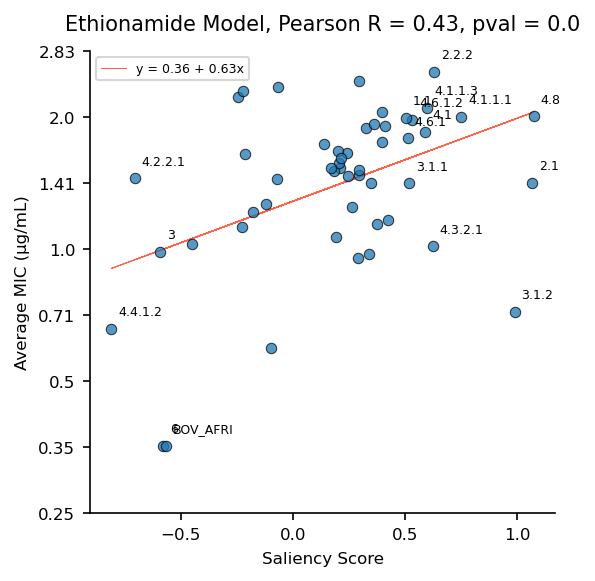

In [60]:
drug = 'ETH'

ETH_significant_lineage_scores = generate_lineage_saliency_plot(drug,
                                                                   f"{drug}_lineage_amino_acid", 
                                                                   annot_thresh=0.5,
                                                                   significance=True,
                                                                   savefName=f"./results/{abbr_drug_dict[drug]}/lineage_saliency_scatter.svg"
                                                                 )

In [39]:
ETH_significant_lineage_scores.query("Max_pval < 0.1 & Min_pval < 0.1")

,position,Max,Min,Lineage,Mean_log2_MIC,log2_MIC,MIC,Num_Isolates,MIC_pval,Max_pval,Min_pval,Bonferroni_MIC_pval,plot_score
4,497491,0.209811,-0.101770,2,0.649278,0.615658,1.532257,3095.0,3.686301e-03,0.0,0.0,2.138055e-01,0.209811
12,931123,0.293661,-0.121453,4**,0.649278,0.559049,1.473297,4201.0,8.852262e-06,0.0,0.0,5.134312e-04,0.293661
18,1491275,0.247922,-0.048798,1.1.3,0.649278,0.554392,1.468549,27.0,7.071656e-01,0.0,0.0,4.101560e+01,0.247922
26,2505085,0.169976,-0.103581,2.2,0.649278,0.616418,1.533064,3069.0,4.422502e-03,0.0,0.0,2.565051e-01,0.169976
33,3388166,0.623074,-0.233621,4.3.2.1,0.649278,0.020896,1.014589,160.0,8.673108e-09,0.0,0.0,5.030403e-07,0.623074
34,3466426,0.120110,-0.448350,4.6,0.649278,0.039327,1.027635,116.0,5.807823e-07,0.0,0.0,3.368537e-05,-0.448350
46,4249732,0.206566,-0.227388,4.7,0.649278,0.165361,1.121447,65.0,2.366921e-03,0.0,0.0,1.372814e-01,-0.227388


56/62 lineages have significant saliency scores
56 lineages have at least 2 isolates
L4.3.1 has both positive and negative significant saliency scores: 0.2318250685930252, -0.03753843158483505
L4.1.2 has both positive and negative significant saliency scores: 0.037413112819194794, -0.03757963329553604
L1.2.2 has both positive and negative significant saliency scores: 0.08734899014234543, -0.03004373237490654
Line of best fit prediction for H37Rv: 0.35
In silico CNN prediction for H37Rv: 0.06


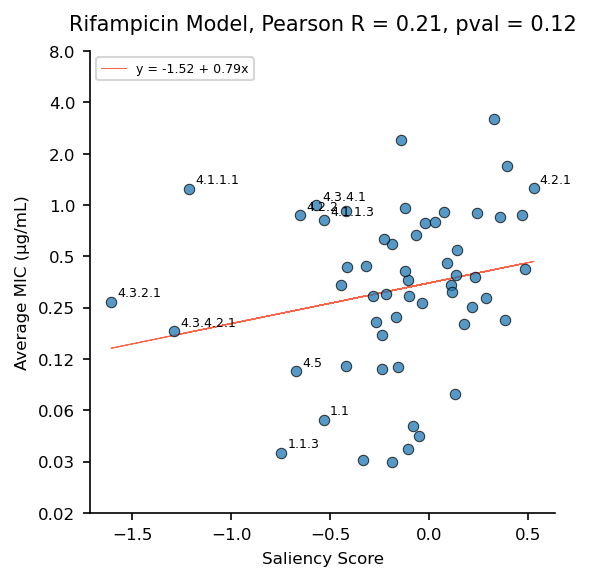

In [63]:
drug = 'RIF'

RIF_significant_lineage_scores = generate_lineage_saliency_plot(drug,
                                                                   f"{drug}_lineage_amino_acid", 
                                                                   annot_thresh=0.5,
                                                                   significance=True,
                                                                   savefName=f"./results/{abbr_drug_dict[drug]}/lineage_saliency_scatter.svg"
                                                                 )

59/62 lineages have significant saliency scores
58 lineages have at least 2 isolates
Line of best fit prediction for H37Rv: 0.089
In silico CNN prediction for H37Rv: 0.051


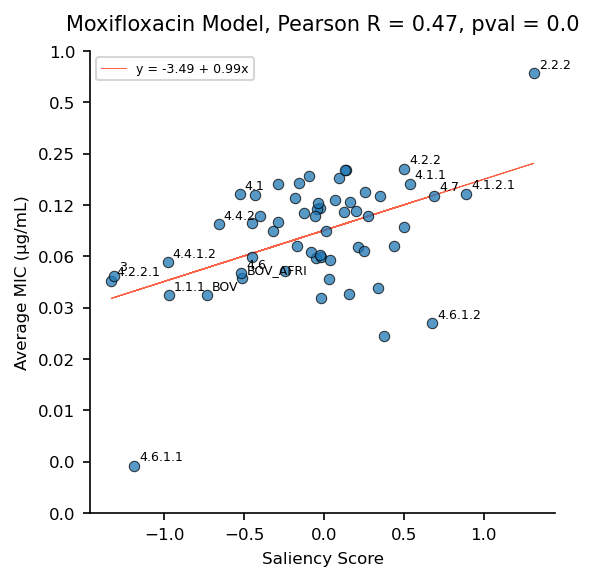

In [61]:
drug = 'MXF'

MXF_significant_lineage_scores = generate_lineage_saliency_plot(drug,
                                                                   f"{drug}_lineage_amino_acid", 
                                                                   annot_thresh=0.5,
                                                                   significance=True,
                                                                   savefName=f"./results/{abbr_drug_dict[drug]}/lineage_saliency_scatter.svg"
                                                                 )

In [47]:
MXF_significant_lineage_scores.query("MIC > 0.25 & plot_score < 0.05")

,position,Max,Min,Lineage,Mean_log2_MIC,log2_MIC,MIC,Num_Isolates,MIC_pval,Max_pval,Min_pval,Bonferroni_MIC_pval,plot_score
43,3570528,-0.0,-0.027715,4.6.2.1,-2.900948,0.584963,1.5,1.0,0.085572,NaN,0.0,5.048727,-0.027715


In [51]:
df_MXF = pd.read_csv(os.path.join(data_dir, "MXF", "data_for_model.csv"))
df_MXF.query("Coll2014=='4.6.2.1'")

,ROLLINGDB_ID,MEDIA_NORM,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
344,SAMEA1101534,7H10,1.0,1.5,2.0,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011568,4.6.2.1,4.2.1.1.1.2.1.1.1.2,cameroon,NaN,4,4,0,1.0,4-1,train_set


In [53]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA1101534' & drug=='Moxifloxacin'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
170539,6588,C,G,PASS,1762.0,False,1.00,52.0,34.0,60.0,0.0,0.0,missense_variant,gyrB,c.1349C>G,p.Pro450Arg,gyrB_p.Pro450Arg,Moxifloxacin,3) Uncertain significance,SAMEA1101534
170541,7362,G,C,PASS,1732.0,False,0.99,57.0,31.0,60.0,0.0,0.0,missense_variant,gyrA,c.61G>C,p.Glu21Gln,gyrA_p.Glu21Gln,Moxifloxacin,5) Not assoc w R,SAMEA1101534
170543,7582,A,G,PASS,1966.0,False,1.00,57.0,34.0,60.0,0.0,0.0,missense_variant,gyrA,c.281A>G,p.Asp94Gly,gyrA_p.Asp94Gly,Moxifloxacin,1) Assoc w R,SAMEA1101534
170545,7585,G,C,PASS,1841.0,False,1.00,54.0,34.0,60.0,0.0,0.0,missense_variant,gyrA,c.284G>C,p.Ser95Thr,gyrA_p.Ser95Thr,Moxifloxacin,5) Not assoc w R,SAMEA1101534
170547,9304,G,A,PASS,1881.0,False,0.99,61.0,32.0,60.0,0.0,0.0,missense_variant,gyrA,c.2003G>A,p.Gly668Asp,gyrA_p.Gly668Asp,Moxifloxacin,5) Not assoc w R,SAMEA1101534


# Is MIC Significantly Elevated in Certain Lineages

In [ ]:
RIF_sig_lineage_scores_df.query("Lineage in ['4.2.1', '2.2.1']")

In [ ]:
RIF_sig_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

In [ ]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [ ]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

# Moxifloxacin Multiloci Models

In [ ]:
# moxi_gyrBA_6Loci_df, moxi_gyrBA_6Loci_seq_dict = generate_saliency_plots("config_moxi_6Loci.yaml",
#                                                              ["MXF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Bedaquiline

In [ ]:
# bdq_no_lineage_df, bdq_no_lineage_seq_dict = generate_saliency_plots("config_bdq_old.yaml",
#                                                              ["BDQ"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
who_single_drug = who_variants.query("drug=='RIF'")

who_pos = who_single_drug["genome_index"].str.split(",", expand=True)
who_pos.columns = ["pos1", "pos2"]

who_single_drug = pd.concat([who_single_drug, who_pos], axis=1).reset_index(drop=True)
print(who_single_drug.shape)

In [ ]:
for i, row in who_single_drug.iterrows():
    
    if not pd.isnull(row["pos2"]):
        
        # duplicate the row and make pos1 to pos2 in the duplicate
        add_row = who_single_drug.iloc[i, :]
        add_row["pos1"] = row["pos2"]
        
        who_single_drug = pd.concat([who_single_drug, pd.DataFrame(add_row).T], axis=0)
        
who_single_drug = who_single_drug.reset_index(drop=True)
del who_single_drug["pos2"]
del who_single_drug["genome_index"]
print(who_single_drug.shape)
who_single_drug.rename(columns={"pos1": "Pos"}, inplace=True)
who_single_drug["Pos"] = who_single_drug["Pos"].astype(float).astype(object)

In [ ]:
# get all sites with positive saliency scores
rif_resistance_analysis = rif_rpoBC_df.query("Max > 0 & max_pVal < 0.05").merge(who_single_drug, on="Pos", how="outer").sort_values("Max", ascending=False)

rif_resistance_analysis = rif_resistance_analysis.query("gene in ['rpoB', 'rpoC']").reset_index(drop=True)

del rif_resistance_analysis["Unnamed: 0"]
print(rif_resistance_analysis.shape)

#new_pos = rif_resistance_analysis.query("confidence in ['3) Uncertain significance', '5) Not assoc w R']")
new_pos = rif_resistance_analysis.loc[(~pd.isnull(rif_resistance_analysis["Max"])) & (rif_resistance_analysis["confidence"] == '3) Uncertain significance')]

print(new_pos.shape)

In [ ]:
for i, row in new_pos.iterrows():
    
    ref = rif_rpoBC_seq_dict["rpoBC"].loc["MT_H37Rv", row["Pos"]]
    alt = rif_rpoBC_seq_dict["rpoBC"][row["Pos"]] != ref
    new_pos.loc[i, "Num_Isolates"] = sum(alt)
    
# new_pos = new_pos.query("Num_Isolates > 5").reset_index(drop=True)
new_pos["Num_Isolates"] = new_pos["Num_Isolates"].astype(int) 
print(new_pos.shape)

In [ ]:
new_pos.sort_values(["Num_Isolates", "Max"], ascending=False)

In [ ]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [ ]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [ ]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [ ]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [ ]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [ ]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [ ]:
test.shape

In [ ]:
4819/(4819+1198)

In [ ]:
1198/(4819+1198)

In [ ]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

In [ ]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())